In [1]:
import pandas as pd
from plotnine import *

import re

from sector_study.config import RAW_DATA_DIR, EXTERNAL_DATA_DIR

print("setup complete!")

2025-10-19 22:36:08.939 | INFO     | sector_study.config:<module>:25 - PROJ_ROOT path is: C:\Users\cjejc\git\sector_study


setup complete!


In [2]:
df = pd.read_parquet("hf://datasets/kurry/sp500_earnings_transcripts/parquet_files/part-0.parquet")

c:\Users\cjejc\git\sector_study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [3]:
df.to_csv(EXTERNAL_DATA_DIR.joinpath("earnings_transcripts.csv"))

In [4]:
df.columns

Index(['symbol', 'quarter', 'year', 'date', 'content', 'structured_content',
       'company_name', 'company_id'],
      dtype='object')

In [5]:
df.shape

(33362, 8)

In [6]:
df["structured_content"].head()

0    [{'speaker': 'Operator', 'text': 'Good afterno...
1    [{'speaker': 'Operator', 'text': 'Good afterno...
2    [{'speaker': 'Operator', 'text': 'Good afterno...
3    [{'speaker': 'Operator', 'text': 'Good afterno...
4    [{'speaker': 'Operator', 'text': 'Good afterno...
Name: structured_content, dtype: object

In [11]:
print(df["date"].head())
df["date"] = pd.to_datetime(df["date"])
print(df["date"].head())

0    2020-11-23 16:30:00
1    2020-08-18 16:30:00
2    2020-05-21 16:30:00
3    2020-02-18 16:30:00
4    2021-11-22 16:30:00
Name: date, dtype: object
0   2020-11-23 16:30:00
1   2020-08-18 16:30:00
2   2020-05-21 16:30:00
3   2020-02-18 16:30:00
4   2021-11-22 16:30:00
Name: date, dtype: datetime64[ns]


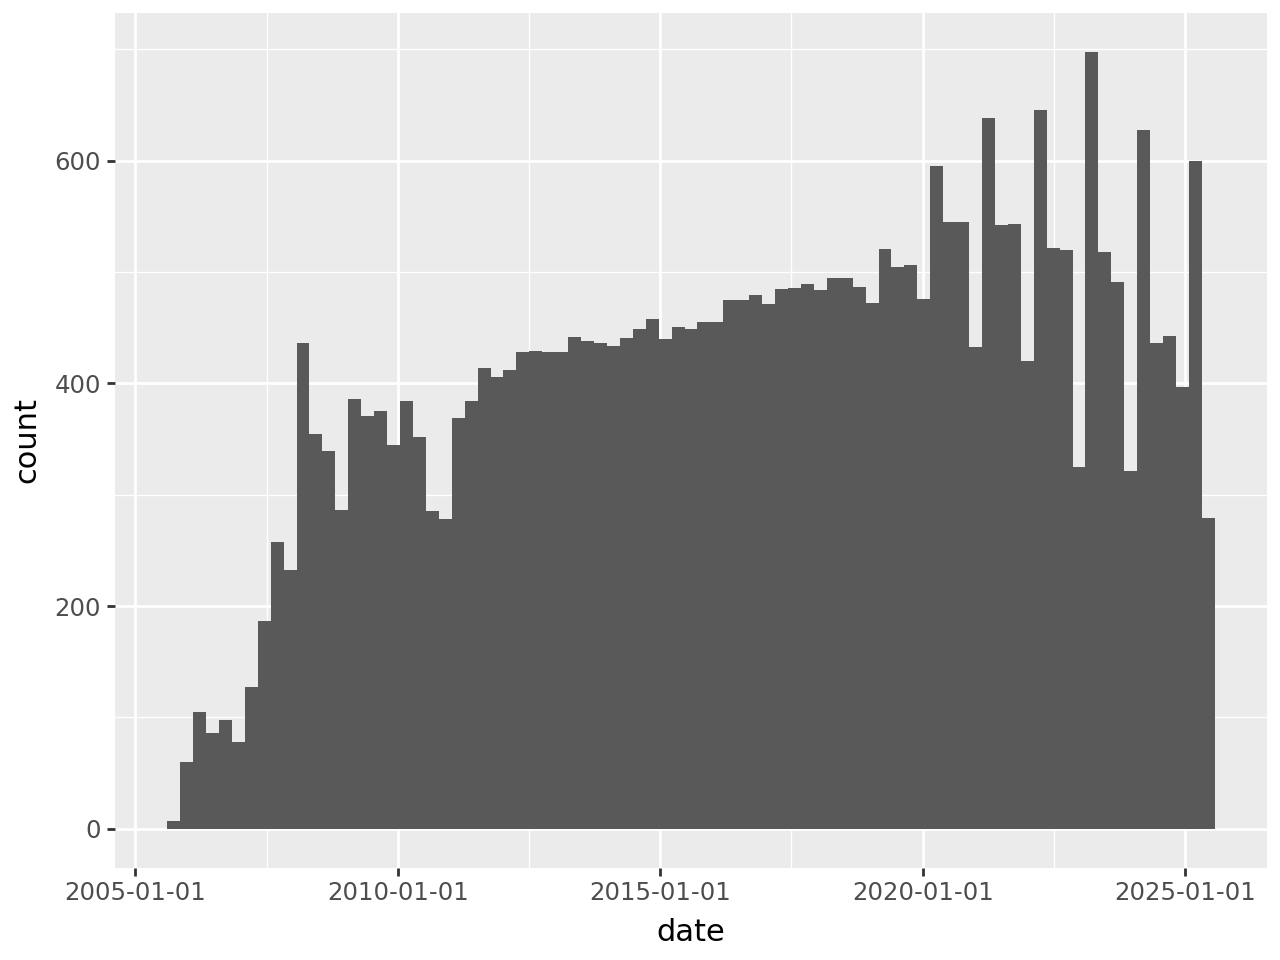

In [12]:
(
  ggplot(df)
  + geom_histogram(aes(x = "date"), binwidth=90)
)